In [2]:
import pandas as pd 
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer



In [3]:
df = pd.read_csv('train.csv',usecols = ['Age','Fare','Survived'])

In [4]:
df['Age'].fillna(df['Age'].mean(),inplace = True)

C:\Users\sangr\AppData\Local\Temp\ipykernel_16800\1652017284.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace = True)


In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [9]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [10]:
X_train, X_test , y_train , y_test = train_test_split(X ,y, test_size = 0.2 , random_state = 42)

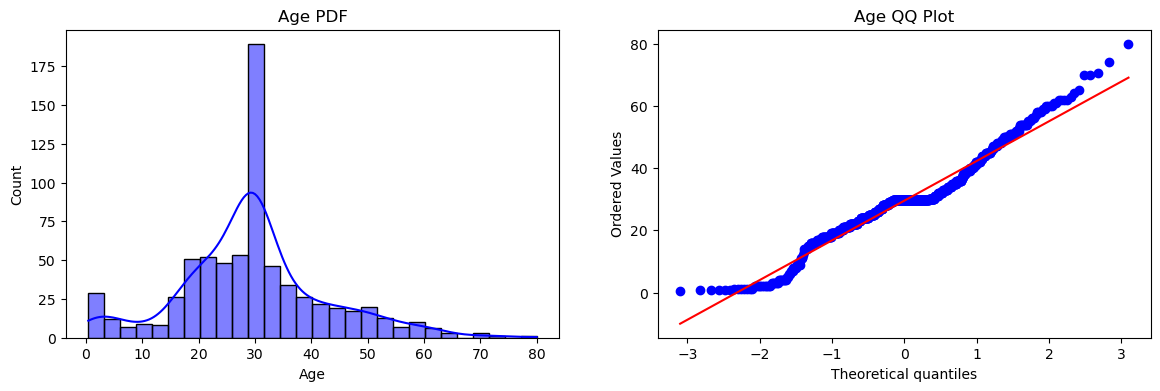

In [12]:
plt.figure(figsize = (14,4))

# Subplot 1: Histogram + KDE (The PDF)
plt.subplot(121)


# Use histplot with kde=True to see the distribution curve
sns.histplot(X_train['Age'], kde=True, color='blue') 
plt.title('Age PDF')

# Subplot 2: QQ Plot
plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

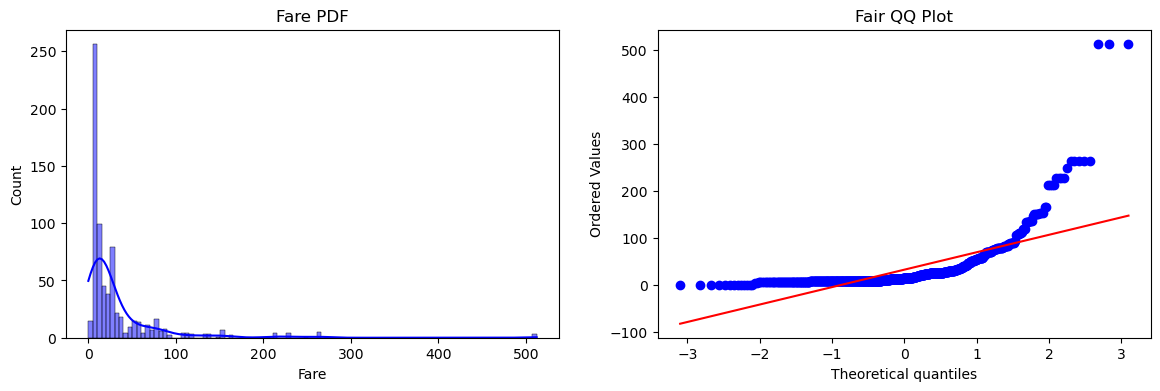

In [14]:
plt.figure(figsize = (14,4))

plt.subplot(121)

sns.histplot(X_train['Fare'], kde = True , color='blue')
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist = 'norm' , plot= plt)
plt.title("Fair QQ Plot")

plt.show()

In [16]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [17]:
clf.fit(X_train, y_train)
clf2.fit(X_train,y_train)

DecisionTreeClassifier()

In [20]:
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))

accuracy LR 0.6480446927374302
Accuracy DT 0.6536312849162011


# Log Transform


In [21]:
trf = FunctionTransformer(func = np.log1p)


In [23]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.fit_transform(X_test)

In [26]:
clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed,y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print("accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred1))

accuracy LR 0.6815642458100558
Accuracy DT 0.6703910614525139


In [30]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf, X_transformed , y, scoring = 'accuracy', cv = 10)))
print("DT" , np.mean(cross_val_score(clf2, X_transformed, y, scoring = 'accuracy', cv = 10)))

# 10 times repitation


LR 0.678027465667915
DT 0.6554931335830212


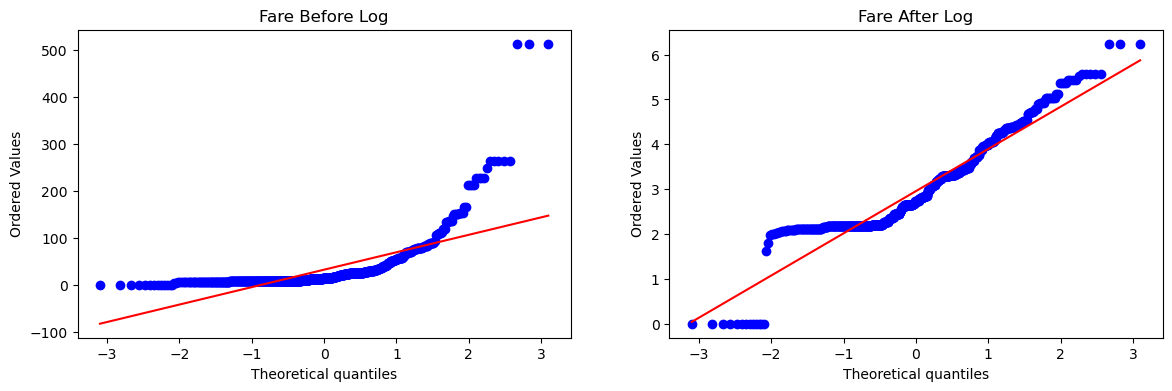

In [31]:
plt.figure(figsize = (14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist= 'norm', plot = plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist= 'norm', plot = plt)
plt.title('Fare After Log')


plt.show()

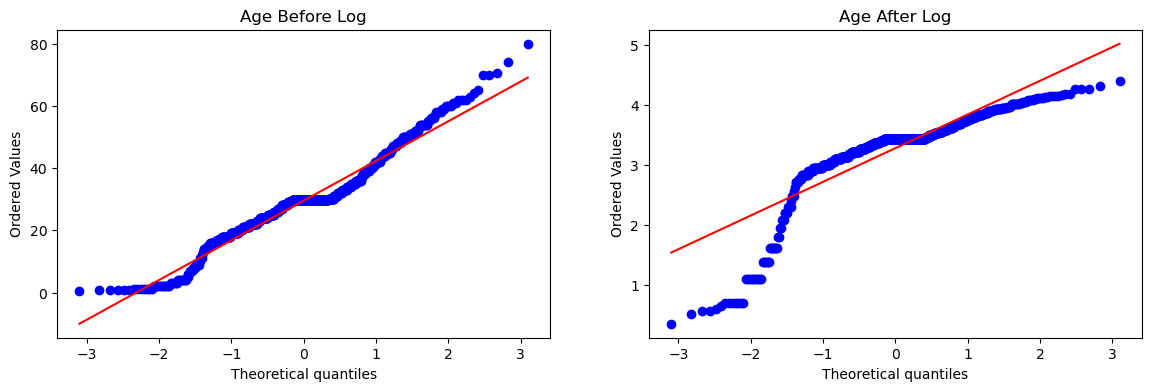

In [32]:
plt.figure(figsize = (14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist= 'norm', plot = plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist= 'norm', plot = plt)
plt.title('Age After Log')


plt.show()

for fare column our log transformation workes well, but for Age columns it is showing Worst results,
we have to work only on fare column , not on Age , that we learned from here 

In [35]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p), ['Fare'])], remainder = 'passthrough')
X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [37]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2, y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("accuracy LR", accuracy_score(y_test, y_pred))
print("Accuracy DT", accuracy_score(y_test, y_pred2))

accuracy LR 0.6703910614525139
Accuracy DT 0.6703910614525139


In [38]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6644444444444444


In [39]:

def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()
    

# Square Transformation

Accuracy 0.6431335830212235


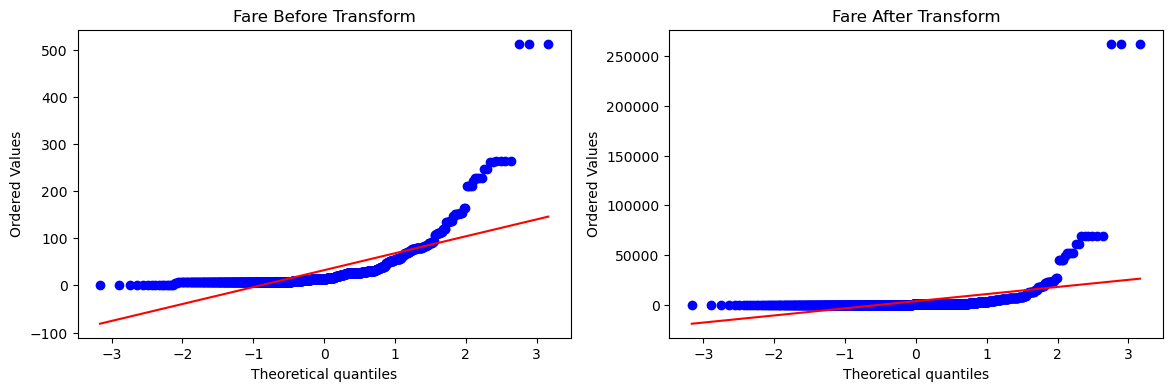

In [41]:
apply_transform(lambda x: x**2)

# Cube Transform

Accuracy 0.6262796504369538


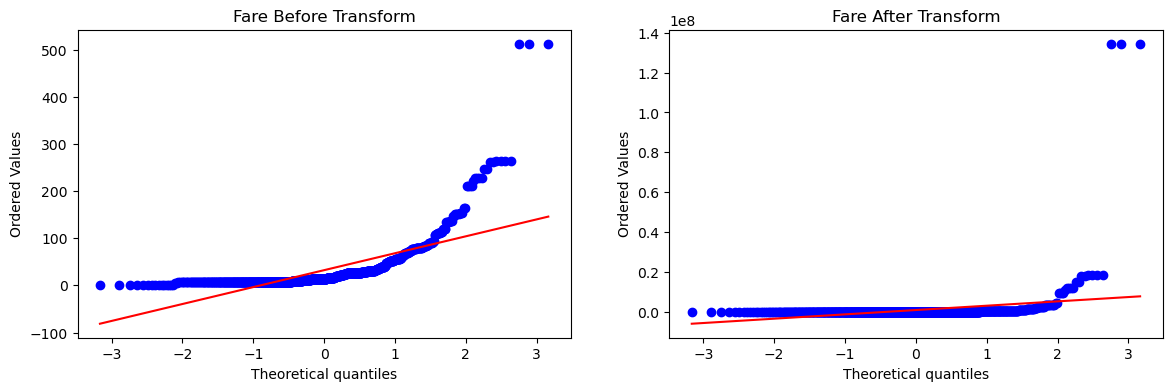

In [42]:
apply_transform(lambda x: x**3)

# Square Root

Accuracy 0.6589013732833957


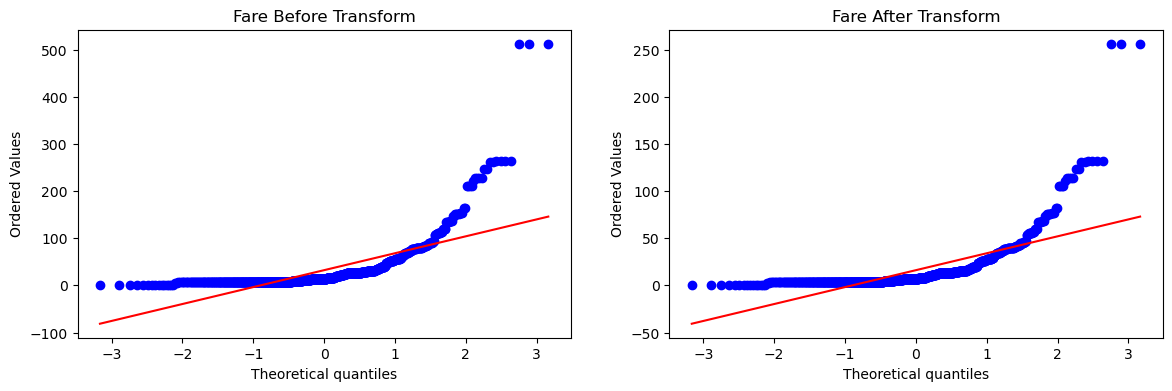

In [43]:
apply_transform(lambda x: x**1/2)

# Reciprocal Transform

Accuracy 0.61729088639201


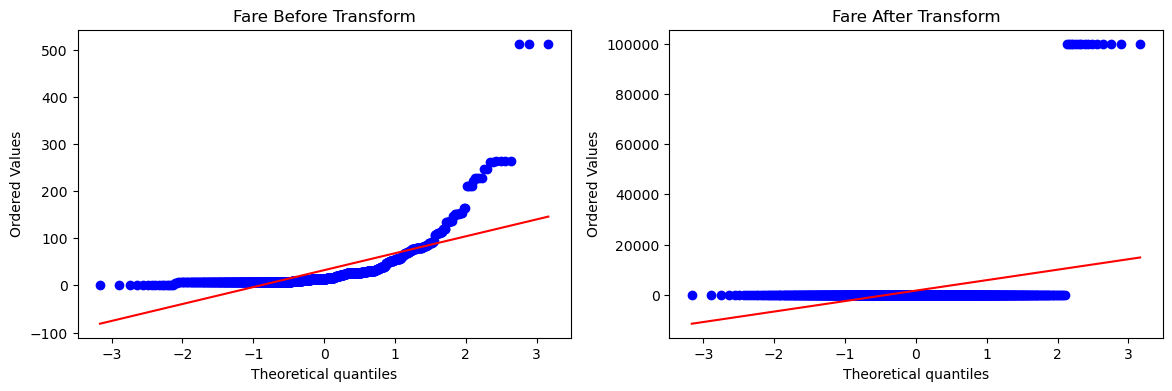

In [45]:
apply_transform(lambda x: 1/(x+0.00001))